In [1]:
#new ds
import pandas as pd
import matplotlib as plt
df = pd.read_csv("prep.csv")
print(df.isnull().sum())
print(df.columns)

genres               0
original_language    0
original_title       0
popularity           0
revenue              0
runtime              0
status               0
title                0
vote_average         0
vote_count           0
userId               0
release_year         0
dtype: int64
Index(['genres', 'original_language', 'original_title', 'popularity',
       'revenue', 'runtime', 'status', 'title', 'vote_average', 'vote_count',
       'userId', 'release_year'],
      dtype='str')


In [2]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
df['label'] = df['vote_average'].apply(lambda x: 1 if x >= 7 else 0)
features = ['revenue', 'runtime', 'popularity', 'vote_count', 'release_year']
X = df[features]

y = df['label']


Correlation with target:

label           1.000000
vote_average    0.388609
vote_count      0.318754
runtime         0.275856
popularity      0.247355
revenue         0.156623
release_year   -0.095699
Name: label, dtype: float64


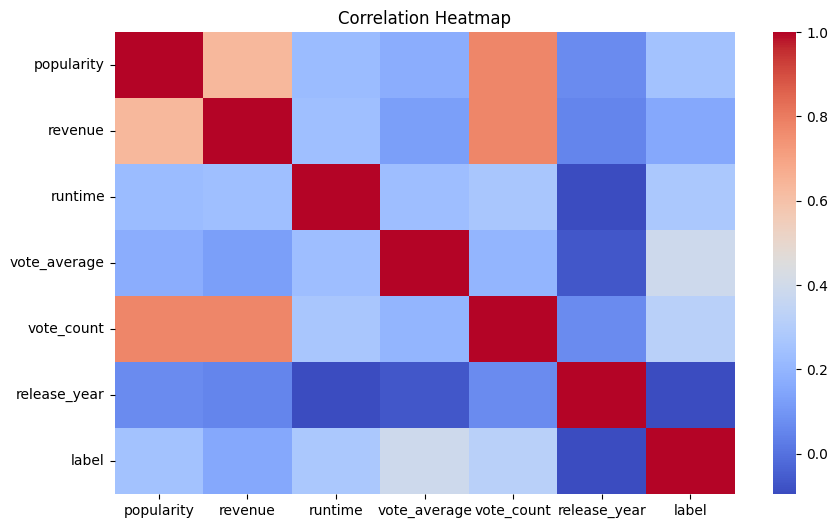

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# CORRELATION
corr = df.corr(numeric_only=True)

print("\nCorrelation with target:\n")
print(corr['label'].sort_values(ascending=False))

plt.figure(figsize=(10,6))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [3]:
#Encode Categorical Columns
# Encode genres (multi-value column)
# SVM MODEL
drop_cols = [
    'title',
    'original_title',
    'overview',
    'homepage',
    'tagline',
    'imdb_id',
    'poster_path',
    'spoken_languages'
]

X = X.drop(columns=drop_cols, errors='ignore')
df['genres'] = df['genres'].str.split()
df = df.explode('genres')
df = pd.get_dummies(df, columns=['genres'], drop_first=True)

# Encode language
df = pd.get_dummies(df, columns=['original_language'], drop_first=True)

# Encode userId
le = LabelEncoder()
df['userId'] = le.fit_transform(df['userId'])

In [4]:
# Feature Selection
X = df.drop(['label', 'vote_average', 'status'], axis=1, errors='ignore')
y = df['label']

# ADD THIS (fix strings → numbers)
X = X.replace('#', 'Unknown')

cat_cols = X.select_dtypes(include=['object', 'string']).columns
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

if 'userId' in X.columns:
    X = X.drop('userId', axis=1)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

i=range(1,5)
for k in i:
    kn= KNeighborsClassifier(n_neighbors=k)
    scores=cross_val_score(kn,X_train,y_train,cv=3)
    print(f"k={k},acc={scores.mean():.2f}")
    

k=1,acc=0.94
k=2,acc=0.86
k=3,acc=0.86
k=4,acc=0.82


In [8]:
from sklearn.metrics import accuracy_score, classification_report

m= KNeighborsClassifier(n_neighbors=3)
m.fit(X_train,y_train)
pred= m.predict(X_test)
print("accuracy:", accuracy_score(y_test,pred))
print("Classification Report:\n", classification_report(y_test, pred))
cm = confusion_matrix(y_test, pred)
print("confusion matrix")
print(cm)

accuracy: 0.9087317265902806
Classification Report:
               precision    recall  f1-score   support

           0       0.90      1.00      0.95      2036
           1       1.00      0.53      0.70       495

    accuracy                           0.91      2531
   macro avg       0.95      0.77      0.82      2531
weighted avg       0.92      0.91      0.90      2531

confusion matrix
[[2036    0]
 [ 231  264]]


In [11]:
#LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
pred = lr.predict(X_test)

print("\n====== Logistic Regression ======")
print("Accuracy:", accuracy_score(y_test, pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))
print("Classification Report:\n", classification_report(y_test,pred))


====== Logistic Regression ======
Accuracy: 0.9699723429474516
Confusion Matrix:
 [[2036    0]
 [  76  419]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98      2036
           1       1.00      0.85      0.92       495

    accuracy                           0.97      2531
   macro avg       0.98      0.92      0.95      2531
weighted avg       0.97      0.97      0.97      2531



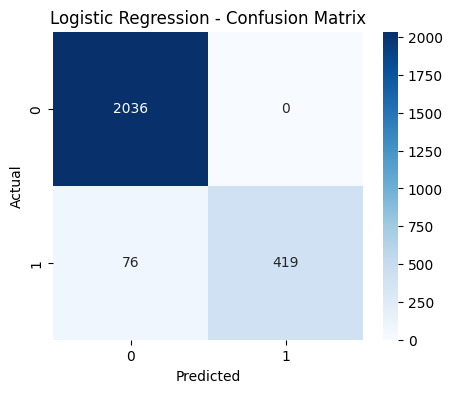

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
svm = SVC(kernel="linear")
svm.fit(X_train, y_train)

pred_svm = svm.predict(X_test)
cm = confusion_matrix(y_test, pred_svm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM - Confusion Matrix")
plt.show()

print("\n========== SVM ==========")
print("Accuracy:", accuracy_score(y_test, pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_svm))
print("Classification Report:\n", classification_report(y_test, pred_svm))


In [ ]:
#roc
prob = m.predict_proba(X_test)[:,1]
fpr,tpr,thresholds = roc_curve(y_test,prob)
roc_auc = auc(fpr,tpr)
print("AUC:", roc_auc)
plt.plot(fpr,tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()
